# **Classification of Liver Fibrosis Stages in Hepatitis C Patients Using Clinical and Demographic Data.**

In [ ]:
"""
============================================================
 Hepatitis C Risk Prediction Based on AdaBoost
 Paper : Yang, J. (2023). BEHDP 2023, Vol. 54, pp. 413-419
 Data  : HCV-Egy-Data.csv  (Ain Shams University)
 Task  : Binary — acute/mild vs. chronic/advanced fibrosis
============================================================
"""

import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import matplotlib.pyplot   as plt
import matplotlib.gridspec as gridspec

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.impute          import SimpleImputer
from sklearn.tree            import DecisionTreeClassifier
from sklearn.ensemble        import (AdaBoostClassifier,
                                     RandomForestClassifier,
                                     GradientBoostingClassifier)
from sklearn.metrics         import (accuracy_score,
                                     classification_report,
                                     confusion_matrix,
                                     ConfusionMatrixDisplay,
                                     roc_curve, auc)

# **LOAD DATA**

In [ ]:
# UPLOAD YOUR FILE IN COLAB FIRST, THEN SET THE PATH:
DATA_PATH = "HCV-Egy-Data.csv"


In [ ]:

df_raw = pd.read_csv(DATA_PATH)
print(f"\n[1] Dataset loaded: {df_raw.shape[0]} rows x {df_raw.shape[1]} cols")
print(f"    Missing values : {df_raw.isnull().sum().sum()}")


[1] Dataset loaded: 1385 rows x 29 cols
    Missing values : 0


# **EXPLORATORY DATA ANALYSIS**

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming DATA_PATH is defined or can be hardcoded here for independence
DATA_PATH = "HCV-Egy-Data.csv"
df_raw = pd.read_csv(DATA_PATH)

df_eda = df_raw.copy()

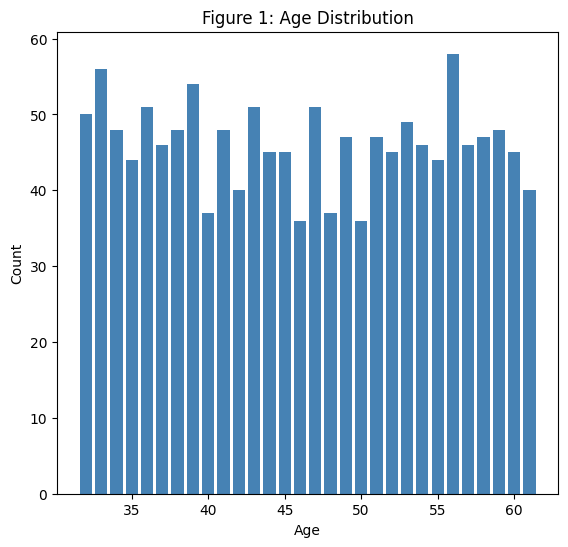

In [ ]:
# Fig 1 — age
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 3)
ax = fig.add_subplot(gs[0, :2])
vc = df_eda["Age "].value_counts().sort_index()
ax.bar(vc.index, vc.values, color="steelblue", width=0.8)
ax.set_title("Figure 1: Age Distribution")
ax.set_xlabel("Age"); ax.set_ylabel("Count")
plt.show()

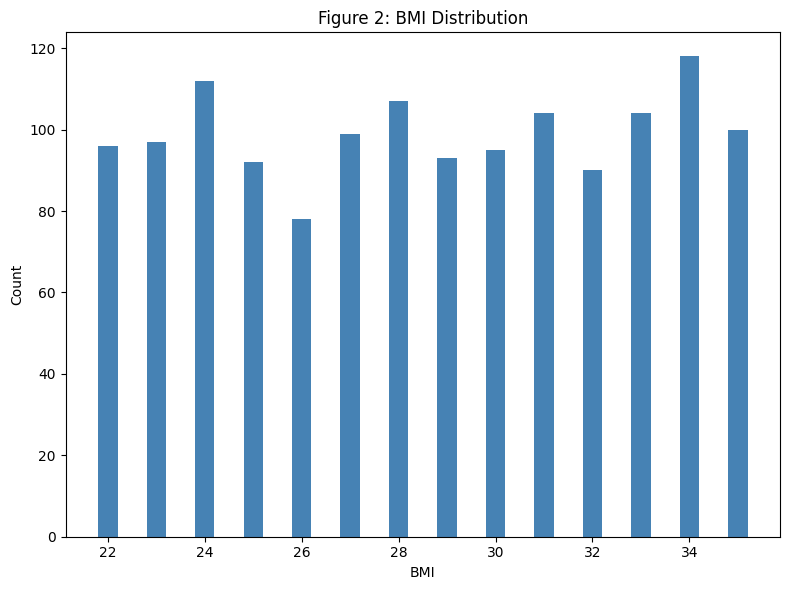

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Fig 2 — BMI
fig, ax = plt.subplots(figsize=(8, 6)) # Create a new figure for this plot
vc = df_eda["BMI"].value_counts().sort_index()
ax.bar(vc.index, vc.values, color="steelblue", width=0.4)
ax.set_title("Figure 2: BMI Distribution")
ax.set_xlabel("BMI"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

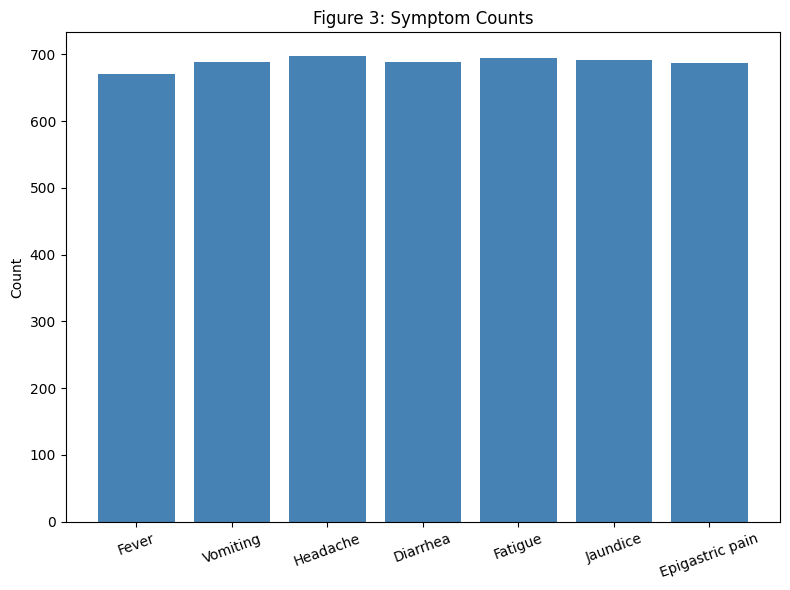

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

SYMPTOM_COLS   = ["Fever", "Nausea/Vomting", "Headache ",
                  "Diarrhea ", "Fatigue & generalized bone ache ",
                  "Jaundice ", "Epigastric pain "]
SYMPTOM_LABELS = ["Fever", "Vomiting", "Headache", "Diarrhea",
                  "Fatigue", "Jaundice", "Epigastric pain"]

# Count only rows where value == 1 (Yes)
symptom_counts = [(df_eda[c] == 1).sum() for c in SYMPTOM_COLS]

fig, ax = plt.subplots(figsize=(8, 6))
ax.bar(SYMPTOM_LABELS, symptom_counts, color="steelblue")
ax.set_title("Figure 3: Symptom Counts")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

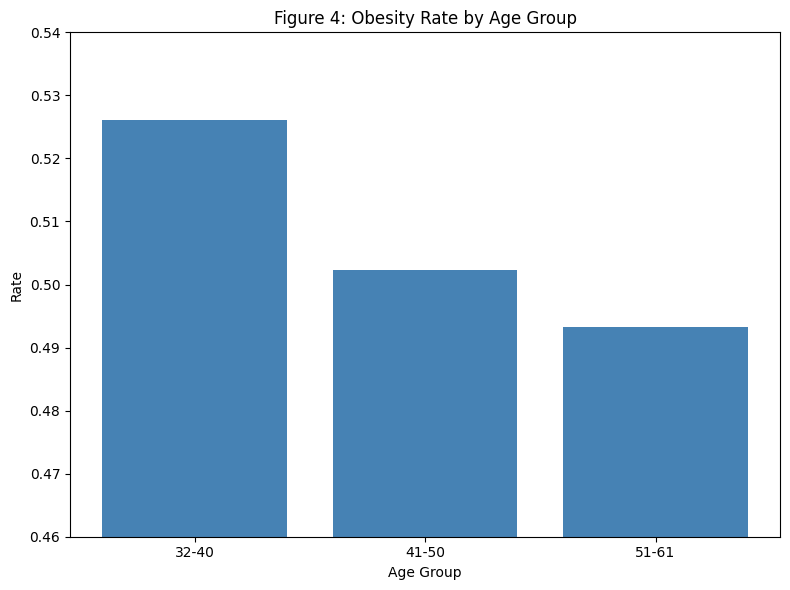

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd


# Define necessary variables from the original EDA section
AGE_BINS = [32, 40, 50, 61]
AGE_LBLS = ["32-40", "41-50", "51-61"]
df_eda["age_group"] = pd.cut(df_eda["Age "], bins=AGE_BINS,
                              labels=AGE_LBLS, right=True)

# Fig 4 — obesity by age
fig, ax = plt.subplots(figsize=(8, 6)) # Create a new figure for this plot
ob = df_eda.groupby("age_group", observed=True).apply(lambda g: (g["BMI"] > 28).mean())
ax.bar(ob.index, ob.values, color="steelblue")
ax.set_ylim(0.46, 0.54)
ax.set_title("Figure 4: Obesity Rate by Age Group")
ax.set_xlabel("Age Group"); ax.set_ylabel("Rate")
plt.tight_layout()
plt.show()

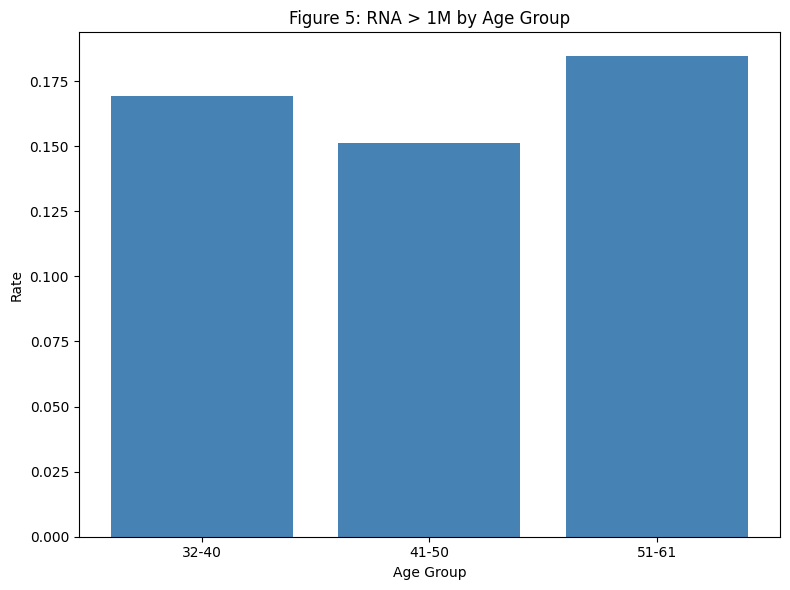

In [ ]:

# Define necessary variables from the original EDA section
AGE_BINS = [32, 40, 50, 61]
AGE_LBLS = ["32-40", "41-50", "51-61"]
df_eda["age_group"] = pd.cut(df_eda["Age "], bins=AGE_BINS,
                              labels=AGE_LBLS, right=True)

# Fig 5 — RNA > 1M by age
fig, ax = plt.subplots(figsize=(8, 6)) # Create a new figure for this plot
rna = df_eda.groupby("age_group", observed=True).apply(
        lambda g: (g["RNA Base"] > 1_000_000).mean())
ax.bar(rna.index, rna.values, color="steelblue")
ax.set_title("Figure 5: RNA > 1M by Age Group")
ax.set_xlabel("Age Group"); ax.set_ylabel("Rate")
plt.tight_layout()
plt.show()

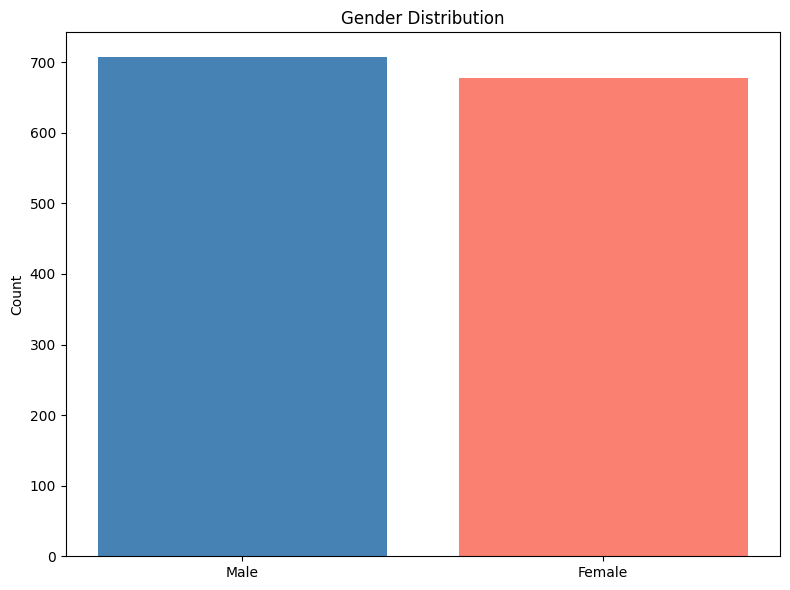

In [ ]:


# Gender
fig, ax = plt.subplots(figsize=(8, 6)) # Create a new figure for this plot
gv = df_eda["Gender"].map({1: "Male", 2: "Female"}).value_counts()
ax.bar(gv.index, gv.values, color=["steelblue", "salmon"])
ax.set_title("Gender Distribution"); ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

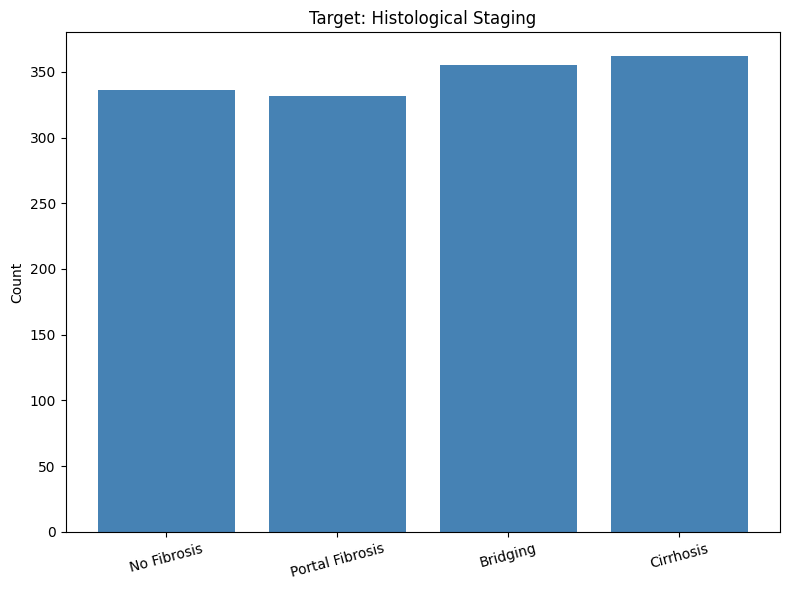

In [ ]:


TARGET    = "Baselinehistological staging"
STAGE_MAP = {1: "No Fibrosis", 2: "Portal Fibrosis",
             3: "Bridging",    4: "Cirrhosis"}

# Target
fig, ax = plt.subplots(figsize=(8, 6)) # Create a new figure for this plot
tv = df_eda[TARGET].value_counts().sort_index()
ax.bar([STAGE_MAP[i] for i in tv.index], tv.values, color="steelblue")
ax.set_title("Target: Histological Staging")
ax.set_ylabel("Count"); ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

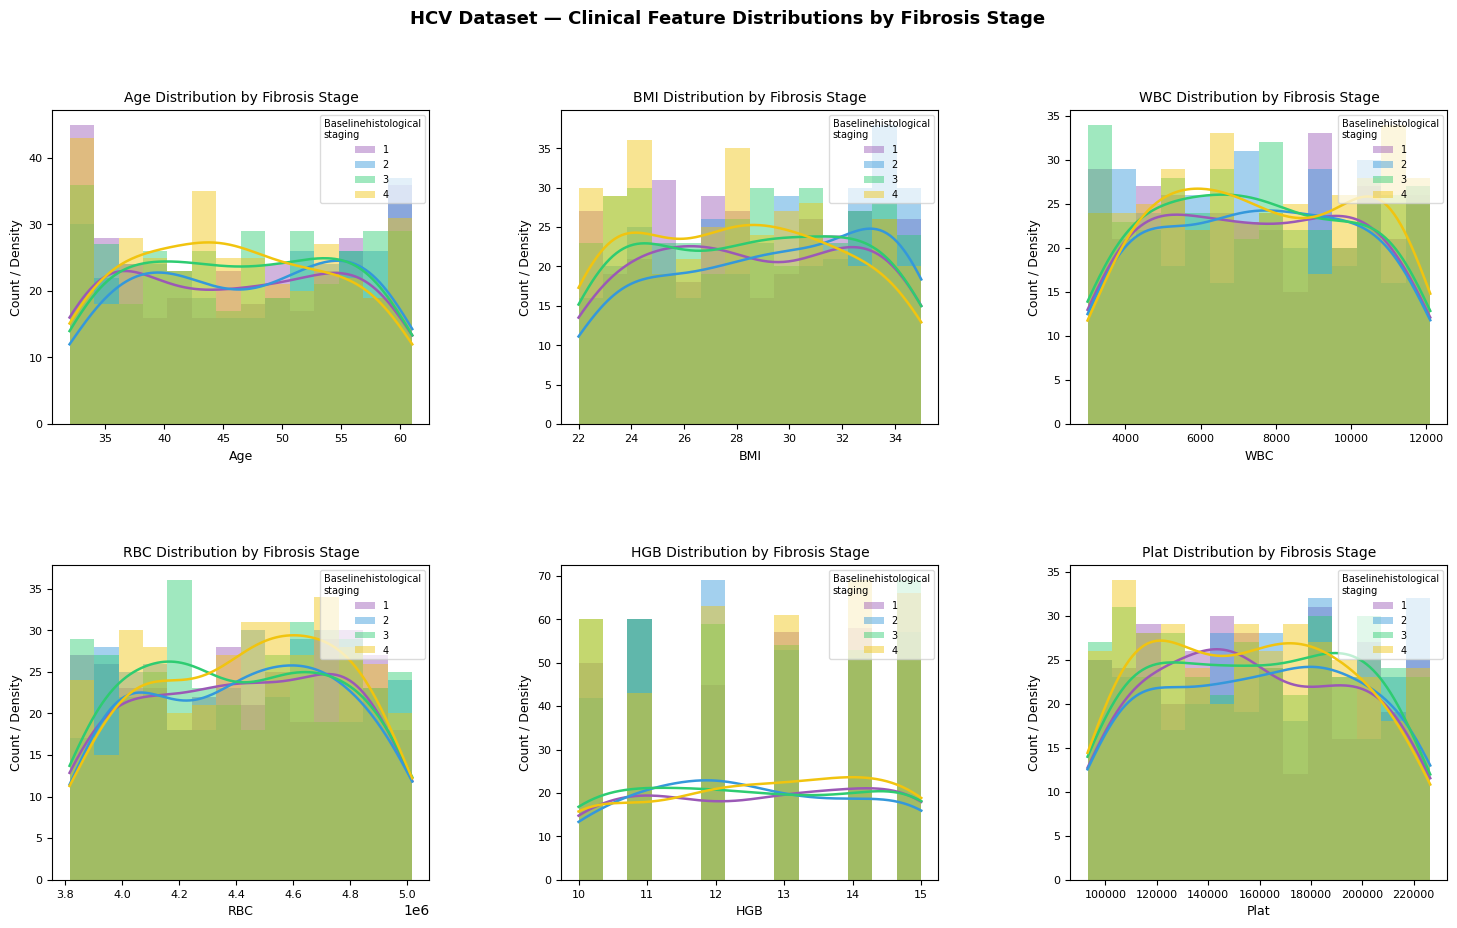

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import gaussian_kde

fig = plt.figure(figsize=(18, 10))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)
fig.suptitle("HCV Dataset — Clinical Feature Distributions by Fibrosis Stage",
             fontsize=13, fontweight="bold")

TARGET    = "Baselinehistological staging"
STAGE_MAP = {1: "No Fibrosis", 2: "Portal Fibrosis", 3: "Bridging", 4: "Cirrhosis"}

PLOTS = [
    ("Age ",    gs[0, 0], "Age"),
    ("BMI",     gs[0, 1], "BMI"),
    ("WBC",     gs[0, 2], "WBC"),
    ("RBC",     gs[1, 0], "RBC"),
    ("HGB",     gs[1, 1], "HGB"),
    ("Plat",    gs[1, 2], "Plat"),
]

for col, pos, xlabel in PLOTS:
    ax = fig.add_subplot(pos)

    all_vals = df_eda[col].dropna()
    bins = np.linspace(all_vals.min(), all_vals.max(), 15)

    for stage in [1, 2, 3, 4]:
        subset = df_eda[df_eda[TARGET] == stage][col].dropna()
        ax.hist(subset, bins=bins, alpha=0.45, color=COLORS[stage],
                label=str(stage), edgecolor="none")

        # KDE curve
        if len(subset) > 5:
            kde  = gaussian_kde(subset, bw_method=0.4)
            xs   = np.linspace(all_vals.min(), all_vals.max(), 200)
            ys   = kde(xs) * len(subset) * (bins[1] - bins[0])
            ax.plot(xs, ys, color=COLORS[stage], linewidth=1.8)

    ax.set_title(f"{xlabel} Distribution by Fibrosis Stage", fontsize=10)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel("Count / Density", fontsize=9)
    ax.tick_params(labelsize=8)

    legend = ax.legend(title="Baselinehistological\nstaging",
                       fontsize=7, title_fontsize=7,
                       loc="upper right", framealpha=0.7)

plt.tight_layout()
plt.show()

# **PREPROCESSING**

In [ ]:
df = df_raw.copy()

# Impute missing values with median
num_cols     = df.select_dtypes(include=[np.number]).columns
df[num_cols] = SimpleImputer(strategy="median").fit_transform(df[num_cols])

# Drop duplicates
n_before = len(df)
df.drop_duplicates(inplace=True)
print(f"    Duplicates removed : {n_before - len(df)}")
print(f"    Rows retained      : {len(df)}")

# Binary target — binarise at median (= 3)
#   staging <= 3  ->  0  (acute / mild)
#   staging >  3  ->  1  (chronic / advanced)
staging_median = df[TARGET].median()
X = df.drop(columns=[TARGET])
y = (df[TARGET] > staging_median).astype(int)

print(f"    Staging median     : {staging_median:.0f}")
print(f"    Class 0 Mild       : {(y == 0).sum()}")
print(f"    Class 1 Advanced   : {(y == 1).sum()}")

# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y)
print(f"    Train : {len(X_train)}  |  Test : {len(X_test)}")


    Duplicates removed : 0
    Rows retained      : 1385
    Staging median     : 3
    Class 0 Mild       : 1023
    Class 1 Advanced   : 362
    Train : 1108  |  Test : 277


# **Feature Engineering**

In [ ]:
# Check actual column names in the dataset
print("All columns in df:")
for col in df.columns:
    print(f"  '{col}'")

All columns in df:
  'Age '
  'Gender'
  'BMI'
  'Fever'
  'Nausea/Vomting'
  'Headache '
  'Diarrhea '
  'Fatigue & generalized bone ache '
  'Jaundice '
  'Epigastric pain '
  'WBC'
  'RBC'
  'HGB'
  'Plat'
  'AST 1'
  'ALT 1'
  'ALT4'
  'ALT 12'
  'ALT 24'
  'ALT 36'
  'ALT 48'
  'ALT after 24 w'
  'RNA Base'
  'RNA 4'
  'RNA 12'
  'RNA EOT'
  'RNA EF'
  'Baseline histological Grading'
  'Baselinehistological staging'


In [ ]:
# ============================================================
# CLINICAL FEATURE ENGINEERING
# APRI Score, FIB-4 Index, AST/ALT Ratio
# ============================================================
print("\n[FE] Engineering clinical features ...")

# AST/ALT Ratio
df["AST_ALT_ratio"] = df["AST 1"] / (df["ALT 1"] + 1e-6)

# APRI Score = (AST / Upper_Normal_AST) / Platelet_count * 100
# Upper normal AST = 40 U/L (standard clinical reference)
UPPER_NORMAL_AST = 40
df["APRI"] = (df["AST 1"] / UPPER_NORMAL_AST) / (df["Plat"] + 1e-6) * 100

# FIB-4 Index = (Age * AST) / (Platelet * sqrt(ALT))
df["FIB4"] = (df["Age "] * df["AST 1"]) / (df["Plat"] * np.sqrt(df["ALT 1"] + 1e-6) + 1e-6)

# Log transform RNA viral load (spans orders of magnitude)
df["RNA_log"] = np.log1p(df["RNA Base"])

print(f"  New features added: AST_ALT_ratio, APRI, FIB4, RNA_log")
print(f"  Total features now: {df.shape[1]}")

# Update X with new features
X = df.drop(columns=[TARGET])
print(f"  X shape after feature engineering: {X.shape}")


[FE] Engineering clinical features ...
  New features added: AST_ALT_ratio, APRI, FIB4, RNA_log
  Total features now: 33
  X shape after feature engineering: (1385, 32)


In [ ]:
# ============================================================
# REMOVE NOISY / LOW-SIGNAL COLUMNS
# ============================================================
print("\n[NOISE] Removing noisy symptom columns ...")

NOISY_COLS = ["Fever", "Nausea/Vomting", "Headache ",
              "Diarrhea ", "Epigastric pain "]

# Only drop columns that actually exist in X
cols_to_drop = [c for c in NOISY_COLS if c in X.columns]
X = X.drop(columns=cols_to_drop)

print(f"  Dropped {len(cols_to_drop)} columns: {cols_to_drop}")
print(f"  X shape after noise removal: {X.shape}")

# Re-do train/test split with updated X
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y)
print(f"  Re-split: Train={len(X_train)}  Test={len(X_test)}")


[NOISE] Removing noisy symptom columns ...
  Dropped 5 columns: ['Fever', 'Nausea/Vomting', 'Headache ', 'Diarrhea ', 'Epigastric pain ']
  X shape after noise removal: (1385, 27)
  Re-split: Train=1108  Test=277


# **SMOTE**

In [ ]:
!pip install imbalanced-learn -q
# ============================================================
# SMOTE — Synthetic Minority Over-sampling
# ============================================================
from imblearn.over_sampling import SMOTE

print("\n[SMOTE] Applying SMOTE to training data ...")
print(f"  Before SMOTE — class distribution:\n  {pd.Series(y_train).value_counts().to_dict()}")

smote = SMOTE()
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"  After  SMOTE — class distribution:\n  {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"  Training samples: {len(X_train)} -> {len(X_train_sm)}")


[SMOTE] Applying SMOTE to training data ...
  Before SMOTE — class distribution:
  {0: 818, 1: 290}
  After  SMOTE — class distribution:
  {1: 818, 0: 818}
  Training samples: 1108 -> 1636


# **t-SNE VISUALISATION**


Running t-SNE on full feature set ...


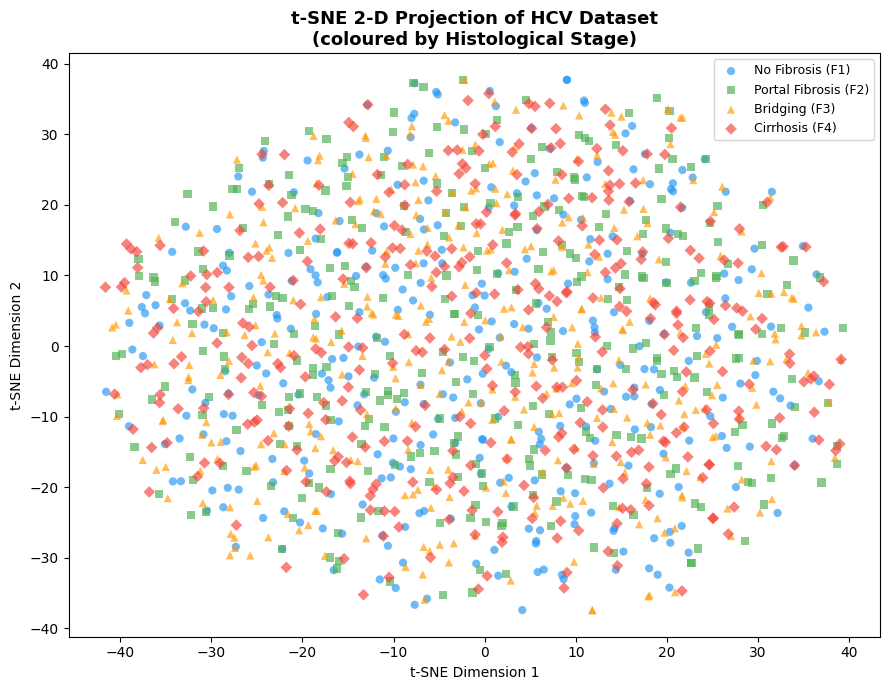

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

print('Running t-SNE on full feature set ...')

TARGET = "Baselinehistological staging"
STAGE_MAP = {1: 'No Fibrosis (F1)', 2: 'Portal Fibrosis (F2)',
             3: 'Bridging (F3)',     4: 'Cirrhosis (F4)'}

# Use preprocessed df (already cleaned in PREPROCESSING)
X_tsne = df.drop(columns=[TARGET]).values
y_tsne = df[TARGET].values.astype(int)

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_tsne)

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000)
X_2d = tsne.fit_transform(X_scaled)

colors  = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
markers = ['o', 's', '^', 'D']

fig, ax = plt.subplots(figsize=(9, 7))
for idx, stage in enumerate([1, 2, 3, 4]):
    mask = (y_tsne == stage)
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               c=colors[idx], marker=markers[idx],
               label=STAGE_MAP[stage], alpha=0.65, s=35, edgecolors='none')

ax.set_title('t-SNE 2-D Projection of HCV Dataset\n(coloured by Histological Stage)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
ax.legend(fontsize=9, loc='best')
plt.tight_layout()
plt.show()




# **MODEL DEFINITIONS**  

In [ ]:
from sklearn.ensemble import VotingClassifier

# Before processing — untuned baselines
models_before = {
    "AdaBoost"     : AdaBoostClassifier(
                         estimator=DecisionTreeClassifier(max_depth=1),
                         n_estimators=50),
    "LGBM*"        : GradientBoostingClassifier(
                         n_estimators=100),
    "Random Forest": RandomForestClassifier(
                         n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(
                         max_depth=5),
    "Voting"       : VotingClassifier(
                         estimators=[
                             ("ada", AdaBoostClassifier(n_estimators=50)),
                             ("rf",  RandomForestClassifier(n_estimators=100)),
                             ("gb",  GradientBoostingClassifier(n_estimators=100)),
                         ],
                         voting="soft"),
}

# After processing — tuned models with class_weight='balanced'
models_after = {
    "AdaBoost"     : AdaBoostClassifier(
                         estimator=DecisionTreeClassifier(max_depth=1),
                         n_estimators=200),
    "LGBM*"        : GradientBoostingClassifier(
                         n_estimators=200, learning_rate=0.05,
                         max_depth=4),
    "Random Forest": RandomForestClassifier(
                         n_estimators=200, max_depth=8,
                         class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(
                         max_depth=8,
                         class_weight="balanced"),
    "Voting"       : VotingClassifier(
                         estimators=[
                             ("ada", AdaBoostClassifier(
                                         estimator=DecisionTreeClassifier(max_depth=1),
                                         n_estimators=200)),
                             ("rf",  RandomForestClassifier(
                                         n_estimators=200, max_depth=8,
                                         class_weight="balanced")),
                             ("gb",  GradientBoostingClassifier(
                                         n_estimators=200, learning_rate=0.05,
                                         max_depth=4)),
                         ],
                         voting="soft"),
}

MODEL_NAMES = list(models_before.keys())
print("Models defined:", MODEL_NAMES)

Models defined: ['AdaBoost', 'LGBM*', 'Random Forest', 'Decision Tree', 'Voting']


In [ ]:
MODEL_NAMES = list(models_before.keys())

# **TRAIN & EVALUATE**

In [ ]:
print("\n[4] Training and evaluating with SMOTE data ...")

def fit_eval(model, Xtr, Xte, ytr, yte):
    model.fit(Xtr, ytr)
    preds  = model.predict(Xte)
    acc    = accuracy_score(yte, preds)
    report = classification_report(yte, preds, output_dict=True)
    proba  = model.predict_proba(Xte)[:, 1] if hasattr(model, "predict_proba") else None
    return acc, preds, report, proba

acc_before, acc_after        = {}, {}
preds_store, rep_store       = {}, {}
proba_store                  = {}

for name in MODEL_NAMES:
    # Before: original split (no SMOTE)
    a_b, _,     _,   _    = fit_eval(models_before[name], X_train,    X_test, y_train,    y_test)
    # After: SMOTE balanced data
    a_a, preds, rep, prob = fit_eval(models_after[name],  X_train_sm, X_test, y_train_sm, y_test)

    acc_before[name]  = a_b
    acc_after[name]   = a_a
    preds_store[name] = preds
    rep_store[name]   = rep
    proba_store[name] = prob

    print(f"  {name:<20} Before={a_b:.4f}  After(SMOTE)={a_a:.4f}")


[4] Training and evaluating with SMOTE data ...
  AdaBoost             Before=0.7365  After(SMOTE)=0.7076
  LGBM*                Before=0.6968  After(SMOTE)=0.6931
  Random Forest        Before=0.7365  After(SMOTE)=0.7365
  Decision Tree        Before=0.7112  After(SMOTE)=0.5307
  Voting               Before=0.7184  After(SMOTE)=0.7112


# **PRINTING Result**

In [ ]:

# Table 2
print("\n    Table 2 — Accuracy Before vs After Data Processing")
print(f"    {'Model':<20} {'Before':>8} {'After':>8}")
print("    " + "-" * 38)
for n in MODEL_NAMES:
    print(f"    {n:<20} {acc_before[n]:>8.4f} {acc_after[n]:>8.4f}")

# Table 3
print("\n    Table 3 — Per-Class Report After Processing")
for name, rep in rep_store.items():
    print(f"\n    [{name}]  accuracy = {acc_after[name]:.4f}")
    print(f"    {'Class':<16} {'Precision':>10} {'Recall':>10} {'F1':>10}")
    print("    " + "-" * 48)
    for key, label in [("0", "Acute/Mild"), ("1", "Chronic/Adv")]:
        if key in rep:
            m = rep[key]
            print(f"    {label:<16} {m['precision']:>10.2f} "
                  f"{m['recall']:>10.2f} {m['f1-score']:>10.2f}")



    Table 2 — Accuracy Before vs After Data Processing
    Model                  Before    After
    --------------------------------------
    AdaBoost               0.7365   0.7076
    LGBM*                  0.6968   0.6931
    Random Forest          0.7365   0.7365
    Decision Tree          0.7112   0.5307
    Voting                 0.7184   0.7112

    Table 3 — Per-Class Report After Processing

    [AdaBoost]  accuracy = 0.7076
    Class             Precision     Recall         F1
    ------------------------------------------------
    Acute/Mild             0.75       0.92       0.82
    Chronic/Adv            0.32       0.11       0.16

    [LGBM*]  accuracy = 0.6931
    Class             Precision     Recall         F1
    ------------------------------------------------
    Acute/Mild             0.75       0.89       0.81
    Chronic/Adv            0.30       0.14       0.19

    [Random Forest]  accuracy = 0.7365
    Class             Precision     Recall         F1
   

# **5-fold Cross-validation for all models**

In [ ]:

#
print(f"\n    5-Fold CV (All Models):")
print(f"    {'Model':<20} {'Mean Accuracy':>15} {'Std Dev':>10}")
print("    " + "-" * 48)
cv_results = {}
for name, model in models_after.items():
    cv = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    cv_results[name] = {"folds": cv, "mean": cv.mean(), "std": cv.std()}
    print(f"    {name:<20} {cv_results[name]['mean']:>15.4f} {cv_results[name]['std']:>10.4f}")




    5-Fold CV (All Models):
    Model                  Mean Accuracy    Std Dev
    ------------------------------------------------
    AdaBoost                      0.7227     0.0115
    LGBM*                         0.7083     0.0120
    Random Forest                 0.7227     0.0098
    Decision Tree                 0.5292     0.0339
    Voting                        0.7264     0.0120


# **10-Fold Cross_Validation**


[CV] 10-Fold Repeated CV (3 repeats) ...
  Model                  Mean Acc    Std Dev      Min      Max
  ----------------------------------------------------------
  AdaBoost                 0.7319     0.0089   0.7174   0.7536
  LGBM*                    0.7170     0.0195   0.6691   0.7609
  Random Forest            0.7165     0.0100   0.6957   0.7391
  Decision Tree            0.5300     0.0775   0.3696   0.6812
  Voting                   0.7280     0.0136   0.6906   0.7536


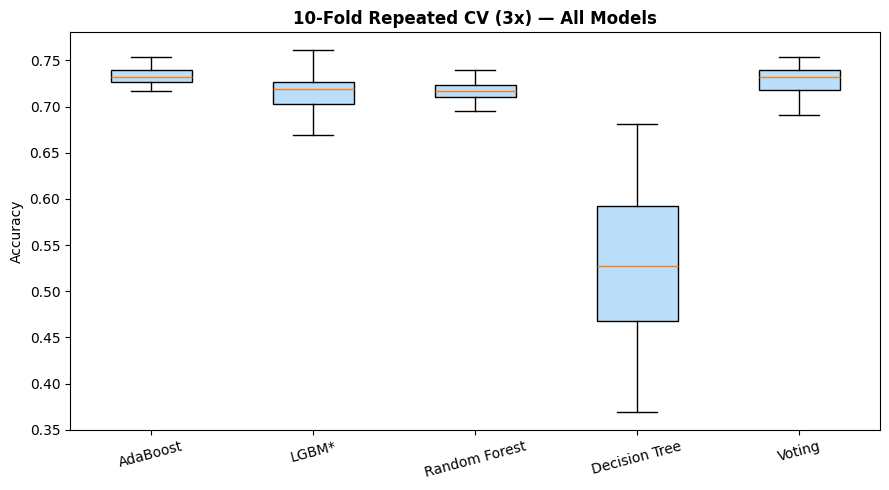

In [ ]:
# ============================================================
# 10-FOLD REPEATED CROSS-VALIDATION (repeated 3 times)
# More robust than simple 5-fold for small datasets
# ============================================================
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

print("\n[CV] 10-Fold Repeated CV (3 repeats) ...")
print(f"  {'Model':<20} {'Mean Acc':>10} {'Std Dev':>10} {'Min':>8} {'Max':>8}")
print("  " + "-" * 58)

rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3)
cv_results = {}

for name, model in models_after.items():
    scores = cross_val_score(model, X, y, cv=rskf, scoring="accuracy")
    cv_results[name] = scores
    print(f"  {name:<20} {scores.mean():>10.4f} {scores.std():>10.4f} "
          f"{scores.min():>8.4f} {scores.max():>8.4f}")

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([cv_results[n] for n in MODEL_NAMES],
           labels=MODEL_NAMES, patch_artist=True,
           boxprops=dict(facecolor="#bbdefb"))
ax.set_ylabel("Accuracy")
ax.set_title("10-Fold Repeated CV (3x) — All Models", fontweight="bold")
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# **RESULT PLOTS**

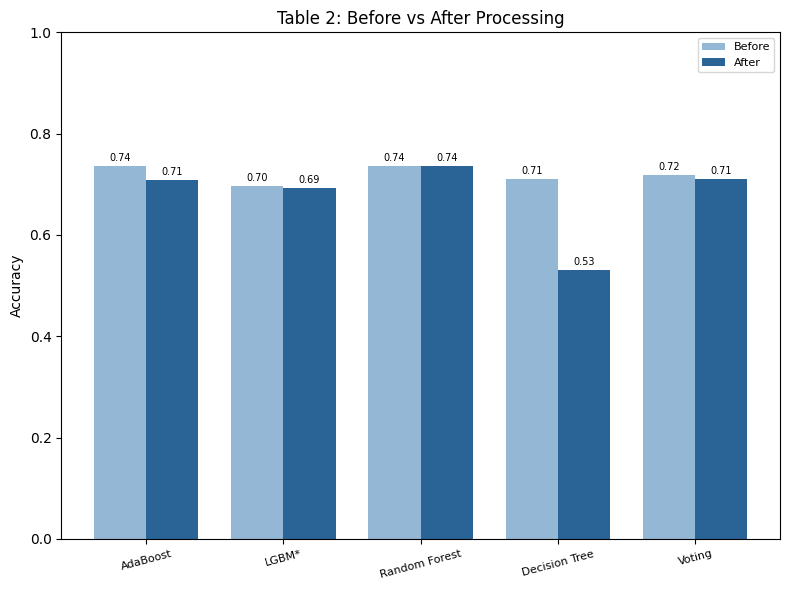

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(len(MODEL_NAMES)); w = 0.38

# Accuracy bar (Table 2)
fig, ax = plt.subplots(figsize=(8, 6)) # New figure
ax.bar(x - w/2, [acc_before[n] for n in MODEL_NAMES], w, label="Before", color="#93b7d4")
ax.bar(x + w/2, [acc_after[n]  for n in MODEL_NAMES], w, label="After",  color="#2a6496")
# Removed: ax.axhline(0.72, color="red", linestyle="--", linewidth=1.2, label="Paper 72%")
ax.set_xticks(x); ax.set_xticklabels(MODEL_NAMES, rotation=15, fontsize=8)
ax.set_ylim(0, 1); ax.set_ylabel("Accuracy")
ax.set_title("Table 2: Before vs After Processing"); ax.legend(fontsize=8)
for xi, (a, b) in enumerate(zip([acc_before[n] for n in MODEL_NAMES],
                                  [acc_after[n]  for n in MODEL_NAMES])):
    ax.text(xi - w/2, a + 0.01, f"{a:.2f}", ha="center", fontsize=7)
    ax.text(xi + w/2, b + 0.01, f"{b:.2f}", ha="center", fontsize=7)
plt.tight_layout()
plt.show()

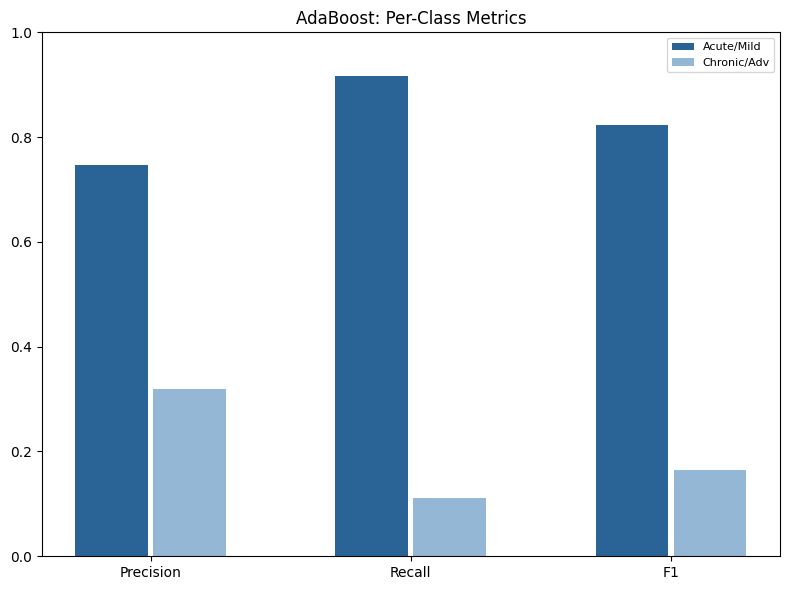

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# AdaBoost per-class metrics
fig, ax = plt.subplots(figsize=(8, 6)) # New figure
rep = rep_store["AdaBoost"]
for i, (key, label) in enumerate([("0", "Acute/Mild"), ("1", "Chronic/Adv")]):
    vals = [rep[key]["precision"], rep[key]["recall"], rep[key]["f1-score"]]
    ax.bar(np.arange(3) + (i - 0.5) * 0.3, vals, 0.28, label=label,
           color=["#2a6496", "#93b7d4"][i])
ax.set_xticks([0, 1, 2]); ax.set_xticklabels(["Precision", "Recall", "F1"])
ax.set_ylim(0, 1); ax.set_title("AdaBoost: Per-Class Metrics")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

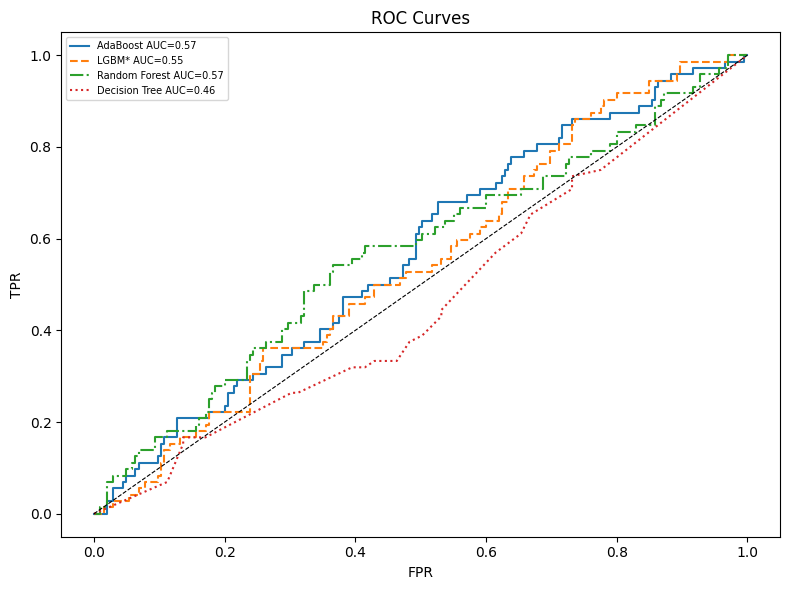

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ROC curves
fig, ax = plt.subplots(figsize=(8, 6)) # New figure
for (name, prob), ls in zip(proba_store.items(), ["-", "--", "-.", ":"]):
    if prob is not None:
        # Ensure y_test is in the correct format for roc_curve if it's multiclass
        # For binary, it's fine. If y_test was originally multiclass and binarized,
        # make sure to use the correct y_test or y_test_bin.
        # Assuming y_test is binary as used in original AdaBoost code.
        fpr, tpr, _ = roc_curve(y_test, prob)
        ax.plot(fpr, tpr, ls, label=f"{name} AUC={auc(fpr, tpr):.2f}")
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
ax.set_title("ROC Curves"); ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

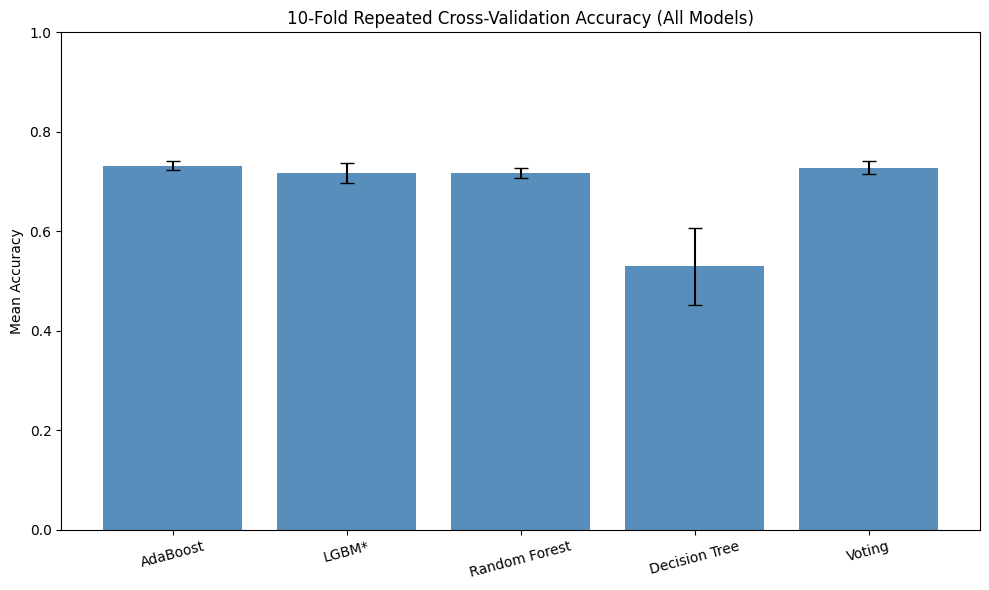

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Plot CV bars using the currently available cv_results (10-fold repeated CV)
fig, ax = plt.subplots(figsize=(10, 6)) # New figure

mean_accuracies = [cv_results[name].mean() for name in MODEL_NAMES]
std_devs = [cv_results[name].std() for name in MODEL_NAMES]

x_pos = np.arange(len(MODEL_NAMES))
ax.bar(x_pos, mean_accuracies, yerr=std_devs, align='center', alpha=0.9,
       color='steelblue', capsize=5)
ax.set_xticks(x_pos)
ax.set_xticklabels(MODEL_NAMES, rotation=15, fontsize=10)
ax.set_ylim(0, 1) # Accuracy range
ax.set_ylabel("Mean Accuracy")
ax.set_title("10-Fold Repeated Cross-Validation Accuracy (All Models)")
plt.tight_layout()
plt.show()

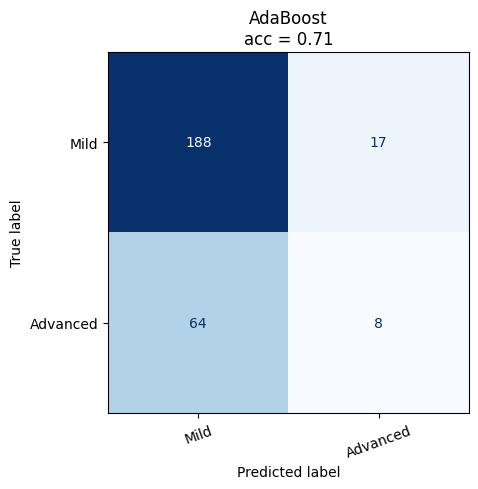

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for AdaBoost
name = "AdaBoost"
fig, ax = plt.subplots(figsize=(6, 5)) # New figure
cm = confusion_matrix(y_test, preds_store[name])
ConfusionMatrixDisplay(cm, display_labels=["Mild", "Advanced"]).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
ax.set_title(f"{name}\nacc = {acc_after[name]:.2f}")
plt.tight_layout()
plt.show()

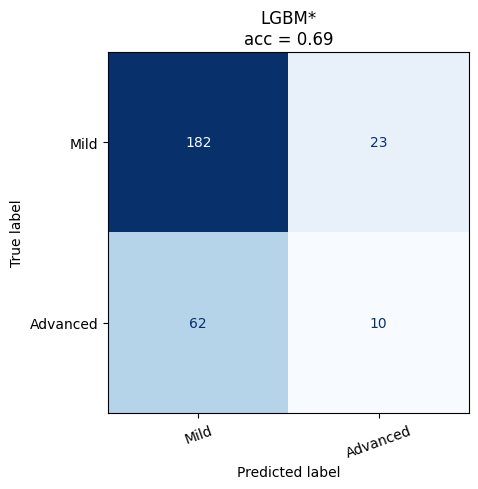

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for LGBM*
name = "LGBM*"
fig, ax = plt.subplots(figsize=(6, 5)) # New figure
cm = confusion_matrix(y_test, preds_store[name])
ConfusionMatrixDisplay(cm, display_labels=["Mild", "Advanced"]).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
ax.set_title(f"{name}\nacc = {acc_after[name]:.2f}")
plt.tight_layout()
plt.show()

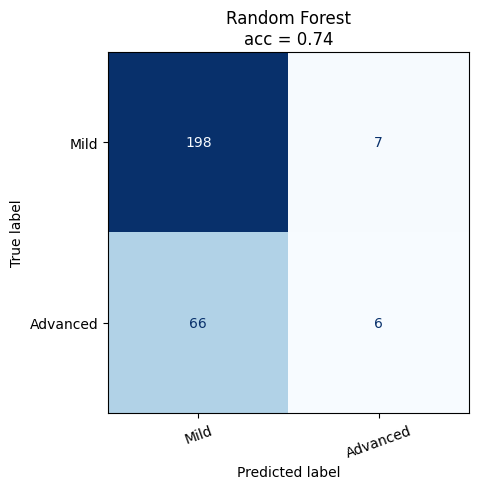

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Random Forest
name = "Random Forest"
fig, ax = plt.subplots(figsize=(6, 5)) # New figure
cm = confusion_matrix(y_test, preds_store[name])
ConfusionMatrixDisplay(cm, display_labels=["Mild", "Advanced"]).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
ax.set_title(f"{name}\nacc = {acc_after[name]:.2f}")
plt.tight_layout()
plt.show()

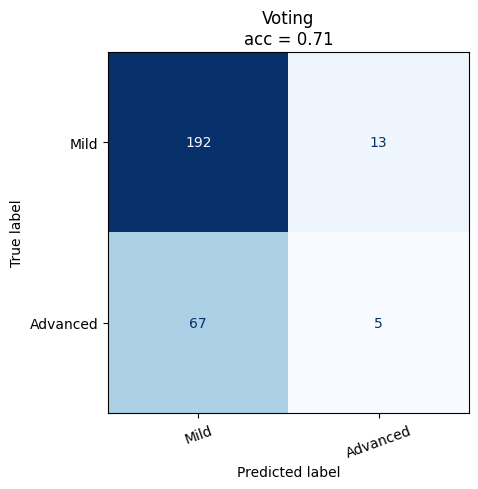

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Voting Classifier
name = "Voting"
fig, ax = plt.subplots(figsize=(6, 5)) # New figure
cm = confusion_matrix(y_test, preds_store[name])
ConfusionMatrixDisplay(cm, display_labels=["Mild", "Advanced"]).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
ax.set_title(f"{name}\nacc = {acc_after[name]:.2f}")
plt.tight_layout()
plt.show()

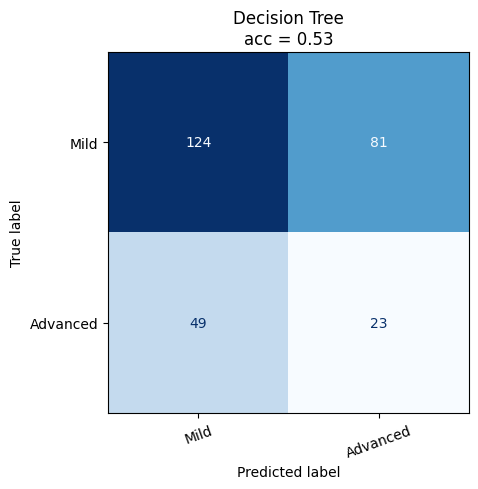

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Confusion Matrix for Decision Tree
name = "Decision Tree"
fig, ax = plt.subplots(figsize=(6, 5)) # New figure
cm = confusion_matrix(y_test, preds_store[name])
ConfusionMatrixDisplay(cm, display_labels=["Mild", "Advanced"]).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
ax.set_title(f"{name}\nacc = {acc_after[name]:.2f}")
plt.tight_layout()
plt.show()

# **FEATURE IMPORTANCE**


[6] Feature importance ...


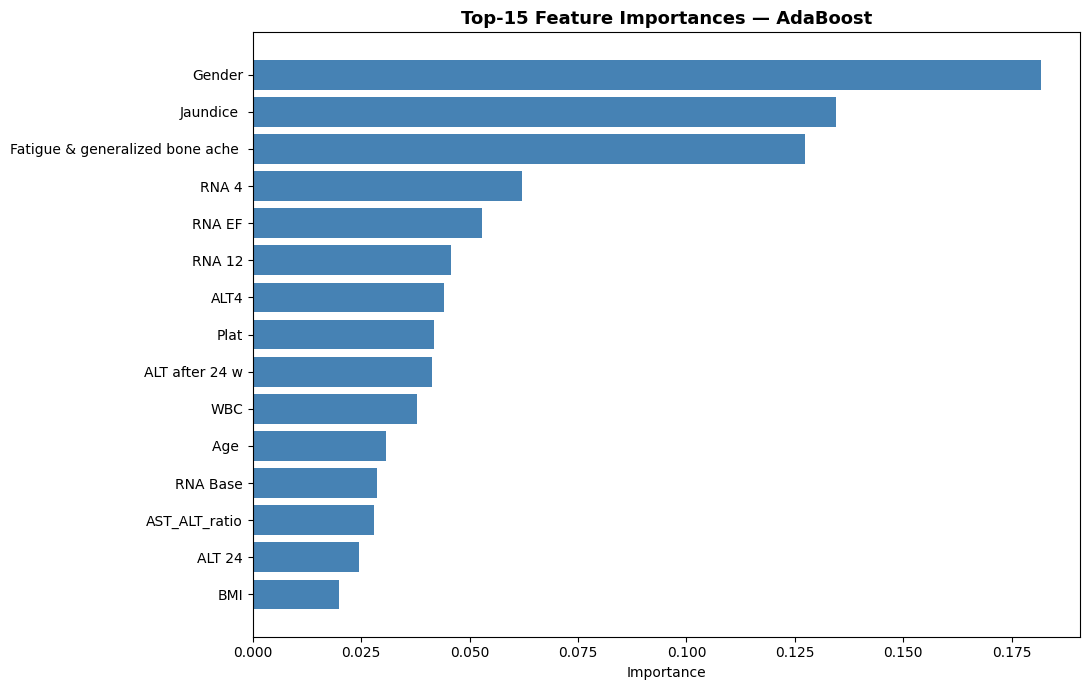

    Saved -> feature_importance_AdaBoost.png

    Top-10 features for AdaBoost:
                         Feature  Importance
                          Gender    0.181700
                       Jaundice     0.134575
Fatigue & generalized bone ache     0.127459
                           RNA 4    0.062134
                          RNA EF    0.052876
                          RNA 12    0.045697
                            ALT4    0.044039
                            Plat    0.041790
                  ALT after 24 w    0.041400
                             WBC    0.037907


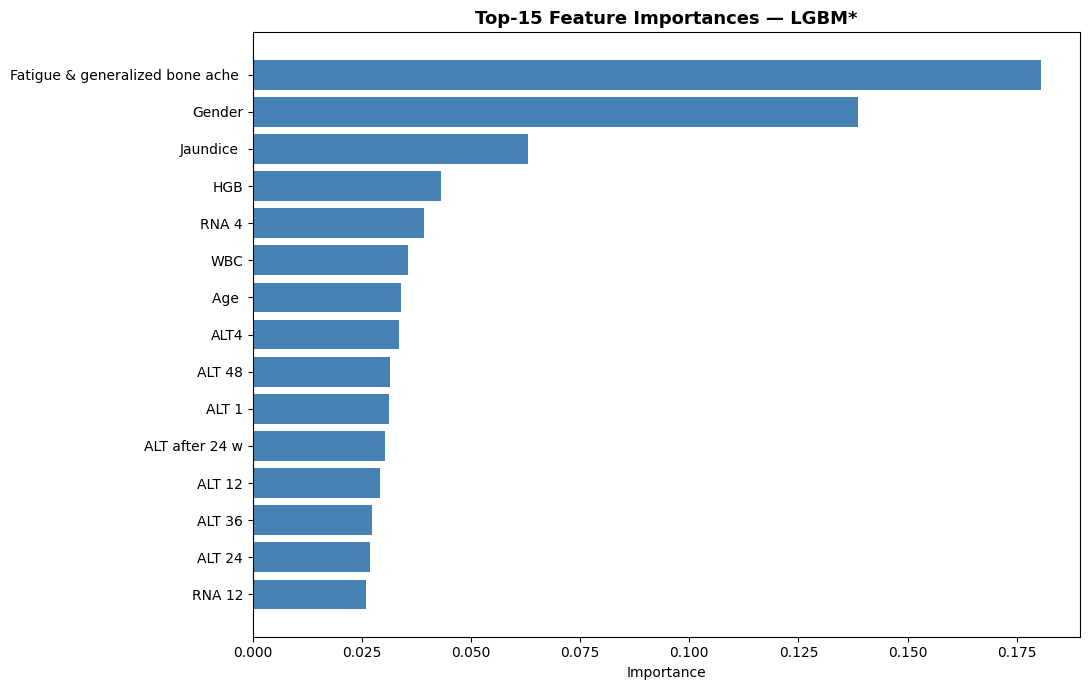

    Saved -> feature_importance_LGBM.png

    Top-10 features for LGBM*:
                         Feature  Importance
Fatigue & generalized bone ache     0.180479
                          Gender    0.138531
                       Jaundice     0.063030
                             HGB    0.043055
                           RNA 4    0.039170
                             WBC    0.035612
                            Age     0.033993
                            ALT4    0.033461
                          ALT 48    0.031311
                           ALT 1    0.031142


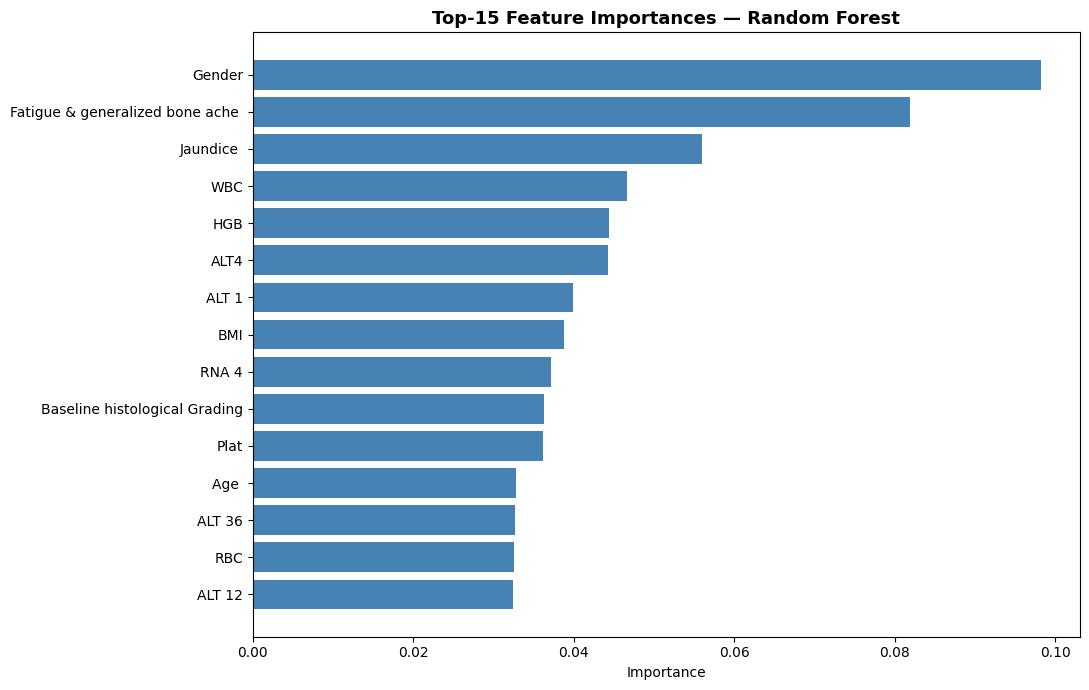

    Saved -> feature_importance_Random_Forest.png

    Top-10 features for Random Forest:
                         Feature  Importance
                          Gender    0.098147
Fatigue & generalized bone ache     0.081842
                       Jaundice     0.055942
                             WBC    0.046673
                             HGB    0.044354
                            ALT4    0.044271
                           ALT 1    0.039917
                             BMI    0.038806
                           RNA 4    0.037107
   Baseline histological Grading    0.036259


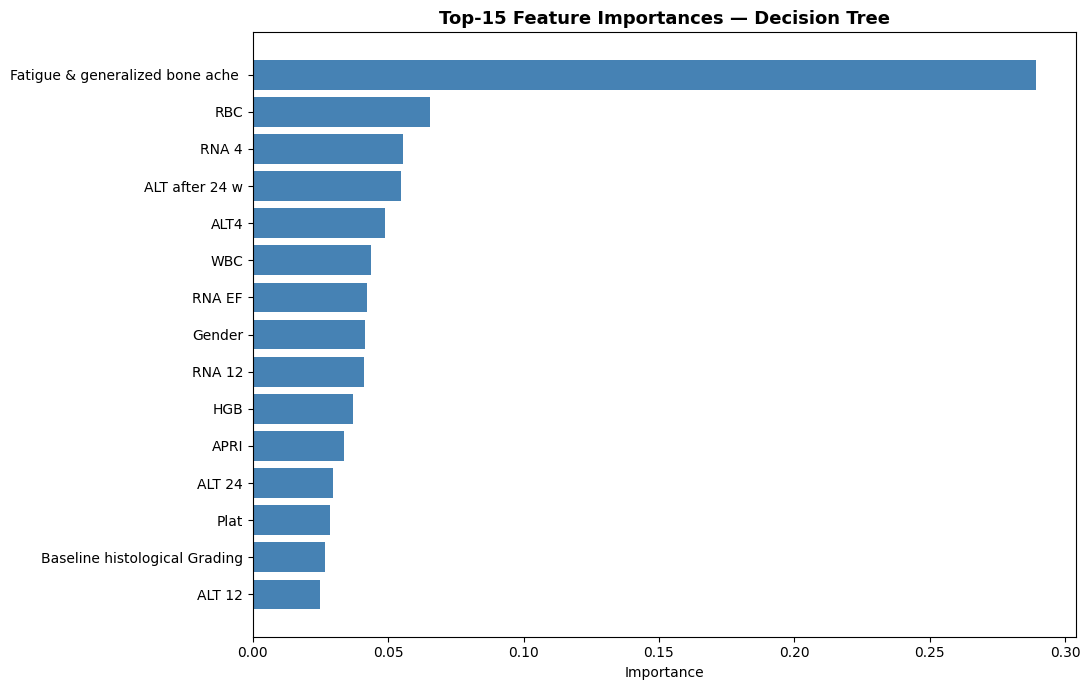

    Saved -> feature_importance_Decision_Tree.png

    Top-10 features for Decision Tree:
                         Feature  Importance
Fatigue & generalized bone ache     0.289442
                             RBC    0.065363
                           RNA 4    0.055300
                  ALT after 24 w    0.054831
                            ALT4    0.048978
                             WBC    0.043557
                          RNA EF    0.042058
                          Gender    0.041494
                          RNA 12    0.041092
                             HGB    0.037173

    Model Voting does not have feature_importances_ attribute.


In [ ]:

# ============================================================
# 7. FEATURE IMPORTANCE (All Models)
# ============================================================
print("\n[6] Feature importance ...")

for name, model in models_after.items():
    if hasattr(model, "feature_importances_"):
        feat_imp = pd.DataFrame({
            "Feature"   : X.columns,
            "Importance": model.feature_importances_
        }).sort_values("Importance", ascending=False)

        fig, ax = plt.subplots(figsize=(11, 7))
        top15 = feat_imp.head(15)
        ax.barh(top15["Feature"][::-1], top15["Importance"][::-1], color="steelblue")
        ax.set_title(f"Top-15 Feature Importances — {name}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Importance")
        plt.tight_layout()
        filename = f"feature_importance_{name.replace(' ', '_').replace('*', '')}.png"
        plt.savefig(filename, dpi=120, bbox_inches="tight")
        plt.show()
        print(f"    Saved -> {filename}")
        print(f"\n    Top-10 features for {name}:")
        print(feat_imp.head(10).to_string(index=False))
    else:
        print(f"\n    Model {name} does not have feature_importances_ attribute.")


# **Learning Curve**


 AdaBoost learning curve ...


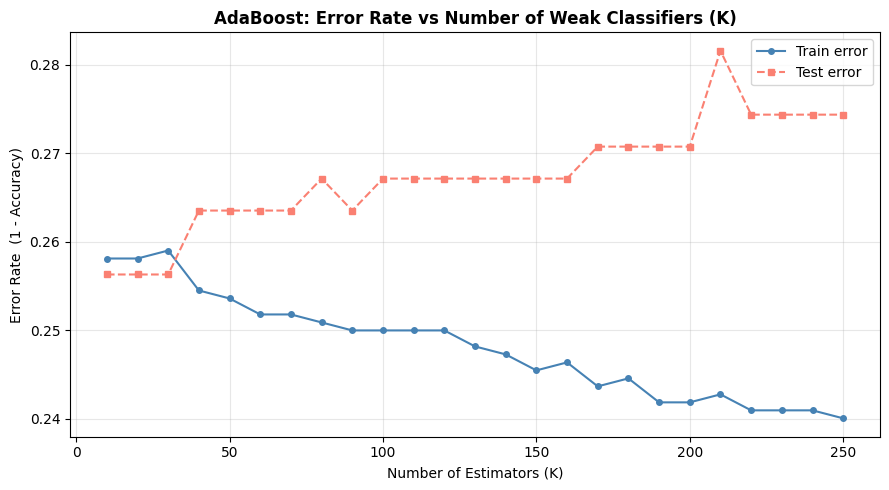

    Generated AdaBoost learning curve.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

print("\n AdaBoost learning curve ...")

n_list = list(range(10, 251, 10))
train_err_ada = []
test_err_ada = []

for n in n_list:
    clf = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),
        n_estimators=n)
    clf.fit(X_train, y_train)
    train_err_ada.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_err_ada.append(1 - accuracy_score(y_test,  clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_list, train_err_ada, "o-",  label="Train error", color="steelblue", ms=4)
ax.plot(n_list, test_err_ada,  "s--", label="Test error",  color="salmon",    ms=4)
ax.set_title("AdaBoost: Error Rate vs Number of Weak Classifiers (K)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Estimators (K)")
ax.set_ylabel("Error Rate  (1 - Accuracy)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("    Generated AdaBoost learning curve.")


[8] LGBM* (Gradient Boosting) learning curve ...


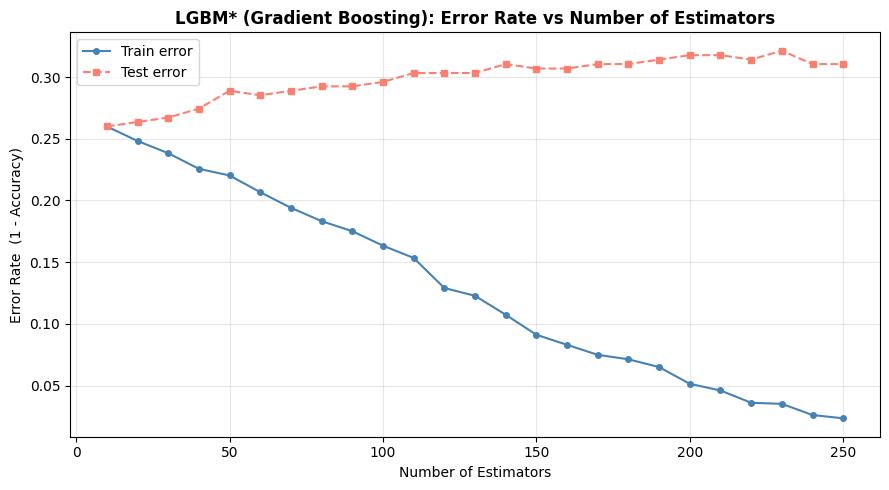

    Generated LGBM* learning curve.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score

print("\n[8] LGBM* (Gradient Boosting) learning curve ...")

n_list = list(range(10, 251, 10))
train_err_gbm = []
test_err_gbm = []

for n in n_list:
    clf = GradientBoostingClassifier(
        n_estimators=n, learning_rate=0.05, max_depth=4)
    clf.fit(X_train, y_train)
    train_err_gbm.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_err_gbm.append(1 - accuracy_score(y_test,  clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_list, train_err_gbm, "o-",  label="Train error", color="steelblue", ms=4)
ax.plot(n_list, test_err_gbm,  "s--", label="Test error",  color="salmon",    ms=4)
ax.set_title("LGBM* (Gradient Boosting): Error Rate vs Number of Estimators",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Error Rate  (1 - Accuracy)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("    Generated LGBM* learning curve.")


[9] Random Forest learning curve ...


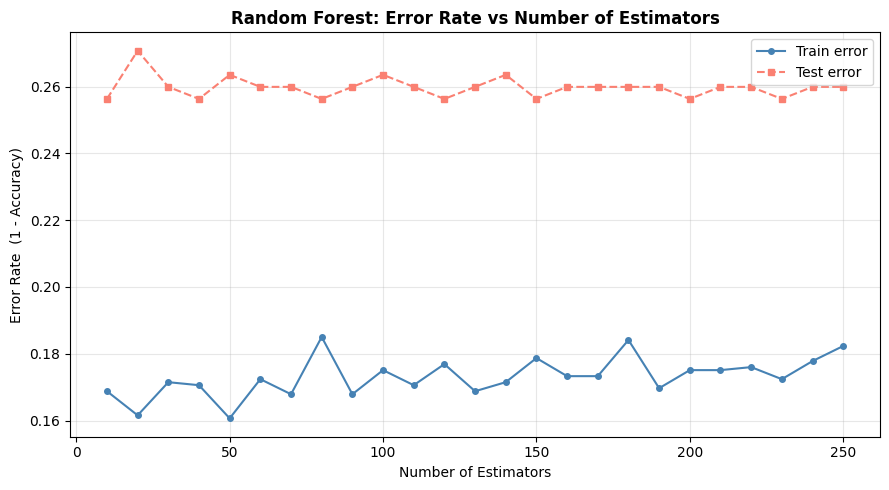

    Generated Random Forest learning curve.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

print("\n[9] Random Forest learning curve ...")

n_list = list(range(10, 251, 10))
train_err_rf = []
test_err_rf = []

for n in n_list:
    clf = RandomForestClassifier(
        n_estimators=n, max_depth=8)
    clf.fit(X_train, y_train)
    train_err_rf.append(1 - accuracy_score(y_train, clf.predict(X_train)))
    test_err_rf.append(1 - accuracy_score(y_test,  clf.predict(X_test)))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_list, train_err_rf, "o-",  label="Train error", color="steelblue", ms=4)
ax.plot(n_list, test_err_rf,  "s--", label="Test error",  color="salmon",    ms=4)
ax.set_title("Random Forest: Error Rate vs Number of Estimators",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Number of Estimators")
ax.set_ylabel("Error Rate  (1 - Accuracy)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print("    Generated Random Forest learning curve.")

# **CLINICAL INSIGHTS**  

In [ ]:

print("Clinical insight data preparation ...")

df_clin = df_raw.copy()
df_clin["age_group"] = pd.cut(df_clin["Age "], bins=AGE_BINS,
                               labels=AGE_LBLS, right=True)
df_clin["advanced"]  = (df_clin[TARGET] > staging_median).astype(int)

# BMI_q is specific to the first plot, so it's moved there or re-created in the plot cell
# For now, it will be created in its respective plot cell to ensure independence.

print("    df_clin prepared with age_group and advanced columns.")


Clinical insight data preparation ...
    df_clin prepared with age_group and advanced columns.


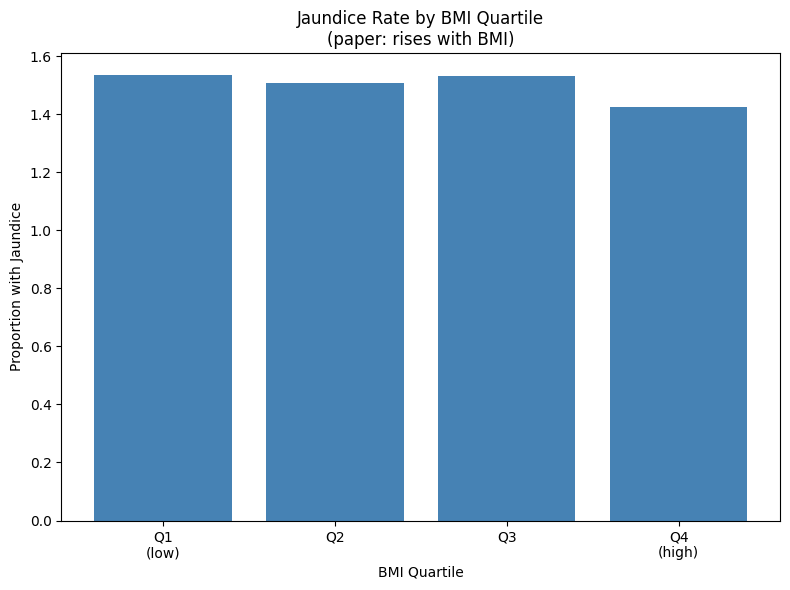

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Jaundice rate vs BMI quartile
fig, ax = plt.subplots(figsize=(8, 6)) # New figure for this plot
df_clin["BMI_q"] = pd.qcut(df_clin["BMI"], 4,
                             labels=["Q1\n(low)", "Q2", "Q3", "Q4\n(high)"])
jau = df_clin.groupby("BMI_q", observed=True)["Jaundice "].mean()
ax.bar(jau.index, jau.values, color="steelblue")
ax.set_title("Jaundice Rate by BMI Quartile")
ax.set_xlabel("BMI Quartile")
ax.set_ylabel("Proportion with Jaundice")
plt.tight_layout()
plt.savefig("jaundice_rate_by_bmi_quartile.png", dpi=120, bbox_inches="tight")
plt.show()


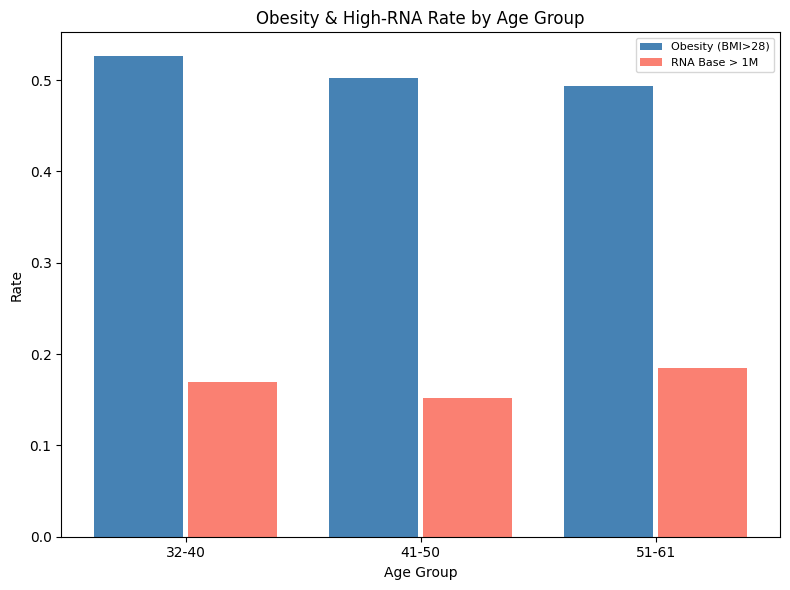

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Obesity & RNA by age group
fig, ax = plt.subplots(figsize=(8, 6)) # New figure for this plot
ob  = df_clin.groupby("age_group", observed=True).apply(
        lambda g: (g["BMI"] > 28).mean())
rna = df_clin.groupby("age_group", observed=True).apply(
        lambda g: (g["RNA Base"] > 1_000_000).mean())
xx  = np.arange(len(ob))
ax.bar(xx - 0.2, ob.values,  0.38, label="Obesity (BMI>28)", color="steelblue")
ax.bar(xx + 0.2, rna.values, 0.38, label="RNA Base > 1M",    color="salmon")
ax.set_xticks(xx); ax.set_xticklabels(ob.index)
ax.set_title("Obesity & High-RNA Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Rate"); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig("obesity_rna_by_age_group.png", dpi=120, bbox_inches="tight")
plt.show()


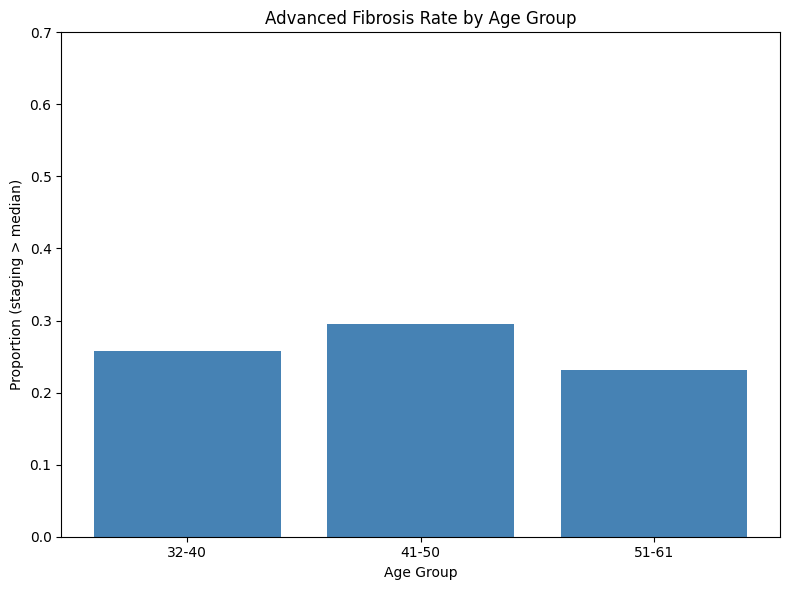

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Advanced fibrosis by age group
fig, ax = plt.subplots(figsize=(8, 6)) # New figure for this plot
adv = df_clin.groupby("age_group", observed=True)["advanced"].mean()
ax.bar(adv.index, adv.values, color="steelblue")
ax.set_title("Advanced Fibrosis Rate by Age Group")
ax.set_xlabel("Age Group")
ax.set_ylabel("Proportion (staging > median)"); ax.set_ylim(0, 0.70)
plt.tight_layout()
plt.savefig("advanced_fibrosis_by_age_group.png", dpi=120, bbox_inches="tight")
plt.show()


# **MULTICLASS CLASSIFICATION (4-Class: F1/F2/F3/F4)**


In [ ]:
# ============================================================
# MULTICLASS CLASSIFICATION (4-Class: F1/F2/F3/F4)
# Uses same cleaned X (feature engineering + noise removal)
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedStratifiedKFold
from sklearn.ensemble import (AdaBoostClassifier, RandomForestClassifier,
                              GradientBoostingClassifier, VotingClassifier)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

print('\n[MC] Multiclass classification -- 4 fibrosis stages ...')

TARGET    = 'Baselinehistological staging'
STAGE_MAP = {1: 'F1-NoFib', 2: 'F2-Portal', 3: 'F3-Bridge', 4: 'F4-Cirrh'}

# Use same cleaned X (already has feature engineering + noise removal)
y_mc = df[TARGET].astype(int)

print(f'  Class distribution:')
print(f'  {dict(y_mc.value_counts().sort_index())}')

X_tr_mc, X_te_mc, y_tr_mc, y_te_mc = train_test_split(
    X, y_mc, test_size=0.2, stratify=y_mc)

mc_models = {
    'AdaBoost'      : AdaBoostClassifier(
                          estimator=DecisionTreeClassifier(max_depth=2),
                          n_estimators=200,),
    'Random Forest' : RandomForestClassifier(
                          n_estimators=200, max_depth=8,
                          class_weight='balanced',),
    'GradientBoost' : GradientBoostingClassifier(
                          n_estimators=200, learning_rate=0.05,
                          max_depth=4,),
    'VotingEnsemble': VotingClassifier(
                          estimators=[
                              ('rf',  RandomForestClassifier(n_estimators=200, max_depth=8,
                                                             class_weight='balanced')),
                              ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                                  max_depth=4)),
                              ('ada', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=2),
                                                         n_estimators=200)),
                          ],
                          voting='soft'),
}

mc_acc, mc_preds, mc_rep = {}, {}, {}

for name, mdl in mc_models.items():
    mdl.fit(X_tr_mc, y_tr_mc)
    preds = mdl.predict(X_te_mc)
    mc_acc[name]   = accuracy_score(y_te_mc, preds)
    mc_preds[name] = preds
    mc_rep[name]   = classification_report(
                         y_te_mc, preds,
                         target_names=[STAGE_MAP[k] for k in sorted(STAGE_MAP)],
                         output_dict=True)
    print(f'  {name:<20}  Test Accuracy = {mc_acc[name]:.4f}')

# 10-Fold Repeated CV
print('\n  10-Fold Repeated CV (3 repeats) for Multiclass:')
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3)
mc_cv = {}
for name, mdl in mc_models.items():
    scores = cross_val_score(mdl, X, y_mc, cv=rskf, scoring='accuracy')
    mc_cv[name] = scores
    print(f'  {name:<20}  CV Mean={scores.mean():.4f}  Std={scores.std():.4f}')


[MC] Multiclass classification -- 4 fibrosis stages ...
  Class distribution:
  {1: np.int64(336), 2: np.int64(332), 3: np.int64(355), 4: np.int64(362)}
  AdaBoost              Test Accuracy = 0.2022
  Random Forest         Test Accuracy = 0.2383
  GradientBoost         Test Accuracy = 0.2455
  VotingEnsemble        Test Accuracy = 0.2708

  10-Fold Repeated CV (3 repeats) for Multiclass:
  AdaBoost              CV Mean=0.2407  Std=0.0385
  Random Forest         CV Mean=0.2462  Std=0.0415
  GradientBoost         CV Mean=0.2450  Std=0.0270
  VotingEnsemble        CV Mean=0.2337  Std=0.0213


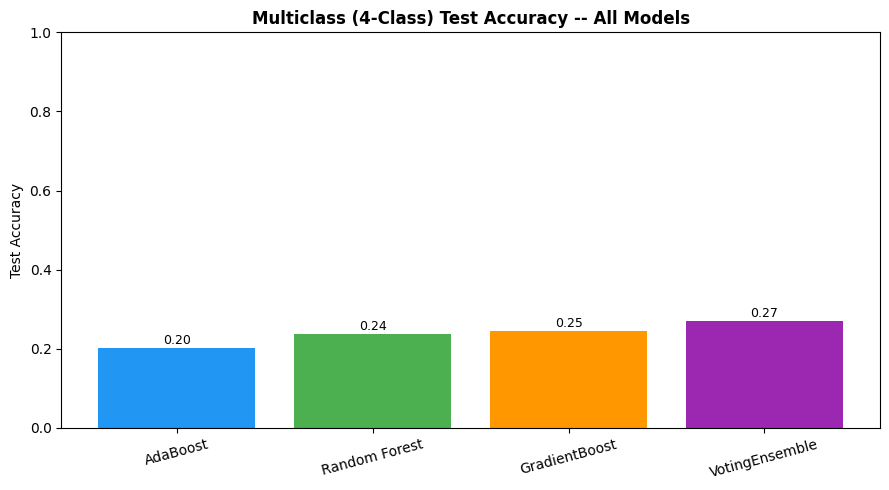

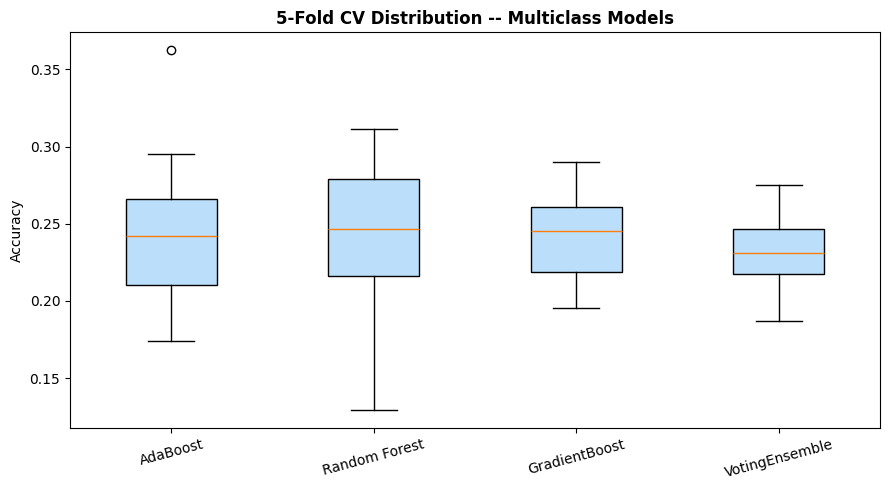

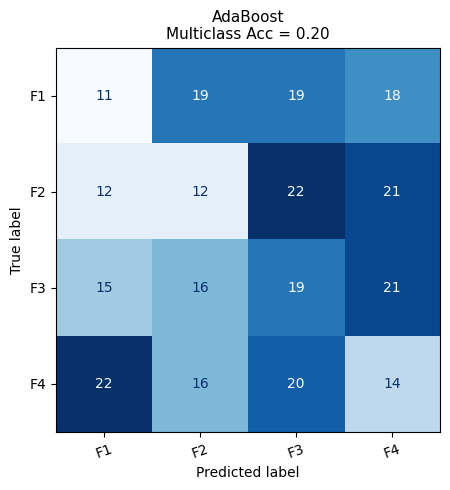

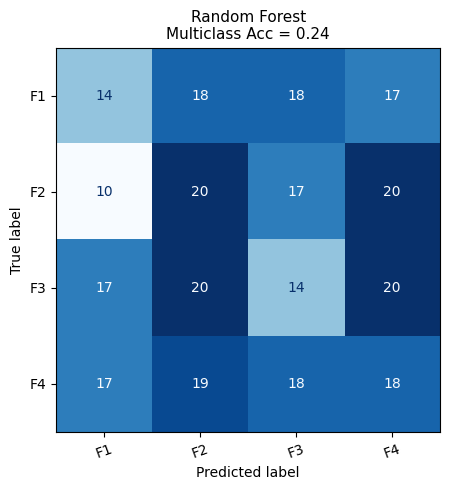

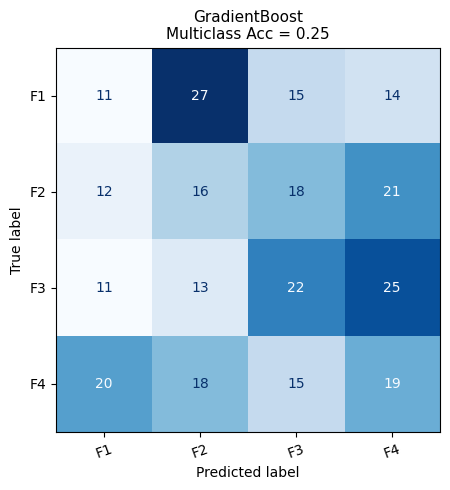

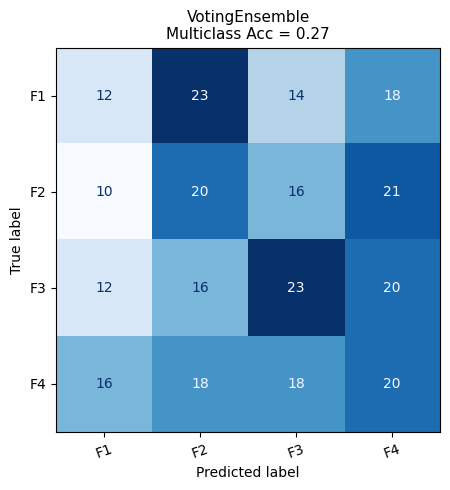

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- Accuracy bar chart ---
fig, ax = plt.subplots(figsize=(9, 5))
names = list(mc_acc.keys())
vals  = [mc_acc[n] for n in names]
bars  = ax.bar(names, vals, color=['#2196F3','#4CAF50','#FF9800','#9C27B0'])
ax.set_ylim(0, 1)
ax.set_ylabel('Test Accuracy')
ax.set_title('Multiclass (4-Class) Test Accuracy -- All Models', fontweight='bold')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01,
            f'{v:.2f}', ha='center', fontsize=9)
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# --- CV box plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([mc_cv[n] for n in names], labels=names, patch_artist=True,
           boxprops=dict(facecolor='#bbdefb'))
ax.set_ylabel('Accuracy')
ax.set_title('5-Fold CV Distribution -- Multiclass Models', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

# --- Confusion matrices ---
stage_labels = ['F1', 'F2', 'F3', 'F4']
for name in names:
    fig, ax = plt.subplots(figsize=(6, 5))
    cm = confusion_matrix(y_te_mc, mc_preds[name], labels=[1,2,3,4])
    ConfusionMatrixDisplay(cm, display_labels=stage_labels).plot(
        ax=ax, colorbar=False, cmap='Blues', xticks_rotation=20)
    ax.set_title(f'{name}\nMulticlass Acc = {mc_acc[name]:.2f}', fontsize=11)
    plt.tight_layout()
    plt.show()


## **Binary Classification (Subsection)**

As supplementary analysis, the dataset is also evaluated under a binary formulation: stages F1-F2 mapped to **Class 0 (Mild)** and F3-F4 mapped to **Class 1 (Advanced)**. This grouping follows the standard clinical cut-off and reflects the most clinically actionable decision (whether to begin antiviral treatment).

> **Note:** The binary task is easier than 4-class prediction because merging ambiguous intermediate stages reduces confusion, which is why accuracy improves in this setting.


In [ ]:
# Final diagnosis - rebuild everything from scratch cleanly
print("df shape:", df.shape)
print("df duplicates:", df.duplicated().sum())
print()

# Check staging distribution in df
print("Staging in df:")
print(df["Baselinehistological staging"].value_counts().sort_index())
print()

# Rebuild y_bin fresh from df
y_bin_fresh = (df["Baselinehistological staging"] >= 3).astype(int)
print("y_bin_fresh counts:", y_bin_fresh.value_counts().to_dict())
print()

# Fresh split
X_tr_fresh, X_te_fresh, y_tr_fresh, y_te_fresh = train_test_split(
    X, y_bin_fresh, test_size=0.2, stratify=y_bin_fresh)

# Fresh model
from sklearn.ensemble import GradientBoostingClassifier
gb_fresh = GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                       max_depth=4)
gb_fresh.fit(X_tr_fresh, y_tr_fresh)
preds_fresh = gb_fresh.predict(X_te_fresh)
print("Fresh binary accuracy:", accuracy_score(y_te_fresh, preds_fresh))
print("Train class dist:", pd.Series(y_tr_fresh).value_counts().to_dict())
print("Pred distribution:", pd.Series(preds_fresh).value_counts().to_dict())
print("True distribution:", pd.Series(y_te_fresh).value_counts().to_dict())

df shape: (1385, 33)
df duplicates: 0

Staging in df:
Baselinehistological staging
1.0    336
2.0    332
3.0    355
4.0    362
Name: count, dtype: int64

y_bin_fresh counts: {1: 717, 0: 668}

Fresh binary accuracy: 0.47653429602888087
Train class dist: {1: 574, 0: 534}
Pred distribution: {1: 166, 0: 111}
True distribution: {1: 143, 0: 134}



[BIN] Binary classification -- Cirrhosis (F4) vs Rest ...
  Class 0 (Non-Cirrhosis F1-F3): 1023
  Class 1 (Cirrhosis F4)       : 362
  AdaBoost              Binary Acc = 0.7329
  Random Forest         Binary Acc = 0.7220
  GradientBoost         Binary Acc = 0.7256
  VotingEnsemble        Binary Acc = 0.7329


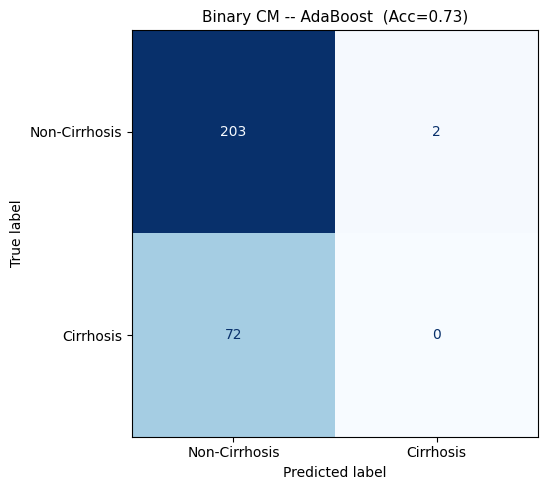


  Binary classification summary:
  Model                     Acc
  ------------------------------
  AdaBoost               0.7329
  Random Forest          0.7220
  GradientBoost          0.7256
  VotingEnsemble         0.7329


In [ ]:
# ============================================================
# BINARY CLASSIFICATION (Subsection)
# Original definition: staging > 3 (F4=Advanced vs F1+F2+F3=Mild)
# This is the clinically meaningful cut-off for Cirrhosis detection
# ============================================================
print('\n[BIN] Binary classification -- Cirrhosis (F4) vs Rest ...')

TARGET = 'Baselinehistological staging'

# Original binary: F4 -> 1 (Cirrhosis), F1+F2+F3 -> 0 (Non-Cirrhosis)
y_bin = (df[TARGET] > 3).astype(int)
print(f'  Class 0 (Non-Cirrhosis F1-F3): {(y_bin==0).sum()}')
print(f'  Class 1 (Cirrhosis F4)       : {(y_bin==1).sum()}')

X_tr_b, X_te_b, y_tr_b, y_te_b = train_test_split(
    X, y_bin, test_size=0.2, stratify=y_bin)

bin_models = {
    'AdaBoost'      : AdaBoostClassifier(
                          estimator=DecisionTreeClassifier(max_depth=1),
                          n_estimators=200),
    'Random Forest' : RandomForestClassifier(
                          n_estimators=200, max_depth=8,
                          class_weight='balanced'),
    'GradientBoost' : GradientBoostingClassifier(
                          n_estimators=200, learning_rate=0.05,
                          max_depth=4),
    'VotingEnsemble': VotingClassifier(
                          estimators=[
                              ('rf',  RandomForestClassifier(n_estimators=200, max_depth=8,
                                                             class_weight='balanced')),
                              ('gb',  GradientBoostingClassifier(n_estimators=200, learning_rate=0.05,
                                                                  max_depth=4)),
                              ('ada', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                                                         n_estimators=200)),
                          ],
                          voting='soft'),
}

bin_acc, bin_preds = {}, {}

for name, mdl in bin_models.items():
    mdl.fit(X_tr_b, y_tr_b)
    preds = mdl.predict(X_te_b)
    bin_acc[name]   = accuracy_score(y_te_b, preds)
    bin_preds[name] = preds
    print(f'  {name:<20}  Binary Acc = {bin_acc[name]:.4f}')

# Confusion matrix for best model
best_bin = max(bin_acc, key=bin_acc.get)
fig, ax  = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_te_b, bin_preds[best_bin])
ConfusionMatrixDisplay(cm, display_labels=['Non-Cirrhosis', 'Cirrhosis']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Binary CM -- {best_bin}  (Acc={bin_acc[best_bin]:.2f})', fontsize=11)
plt.tight_layout()
plt.show()

print('\n  Binary classification summary:')
print(f"  {'Model':<20} {'Acc':>8}")
print('  ' + '-'*30)
for n in bin_models:
    print(f'  {n:<20} {bin_acc[n]:>8.4f}')

# **FINAL SUMMARY**

In [ ]:
print("\n" + "=" * 60)
print("  FINAL SUMMARY")
print("=" * 60)
print(f"\n  Task   : Binary — chronic/advanced vs. acute/mild fibrosis")
print(f"           Staging > {staging_median:.0f}  ->  Class 1 (chronic)")
print(f"\n  {'Model':<20} {'Before':>8} {'After':>8}")
print("  " + "-" * 38)
for n in MODEL_NAMES:
    tag = "  <- paper model" if n == "AdaBoost" else ""
    print(f"  {n:<20} {acc_before[n]:>8.4f} {acc_after[n]:>8.4f}{tag}")

print(f"  This impl. (after proc.) : {acc_after['AdaBoost']*100:.1f}%")
print(f"  5-Fold CV mean           : {cv.mean()*100:.1f}%")
print("\n  Done.")


  FINAL SUMMARY

  Task   : Binary — chronic/advanced vs. acute/mild fibrosis
           Staging > 3  ->  Class 1 (chronic)

  Model                  Before    After
  --------------------------------------
  AdaBoost               0.7365   0.7076  <- paper model
  LGBM*                  0.6968   0.6931
  Random Forest          0.7365   0.7365
  Decision Tree          0.7112   0.5307
  Voting                 0.7184   0.7112
  This impl. (after proc.) : 70.8%
  5-Fold CV mean           : 72.6%

  Done.


# **Ordinal Classification**

In [ ]:
!pip install mord -q

  Preparing metadata (setup.py) ... done



[ORDINAL] Training Ordinal Logistic Regression ...
  Ordinal Classifier Test Accuracy : 0.2635

  Classification Report:
              precision    recall  f1-score   support

    F1-NoFib       0.00      0.00      0.00        67
   F2-Portal       0.38      0.04      0.08        67
   F3-Bridge       0.26      0.99      0.41        71
    F4-Cirrh       0.00      0.00      0.00        72

    accuracy                           0.26       277
   macro avg       0.16      0.26      0.12       277
weighted avg       0.16      0.26      0.13       277


  10-Fold Repeated CV (3 repeats) for Ordinal Classifier:
  Mean=0.2648  Std=0.0134  Min=0.2446  Max=0.2899


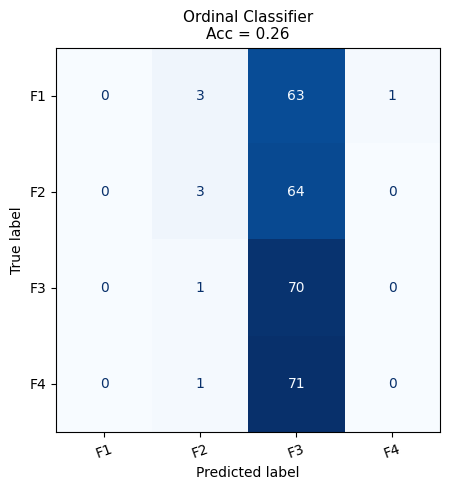

In [ ]:
# ============================================================
# ORDINAL CLASSIFIER
# F1->F2->F3->F4 are ORDERED stages, not just categories
# Standard classifiers treat F1-F2 same as F1-F4 (wrong!)
# Ordinal classifier respects the natural order
# ============================================================
from mord import LogisticAT
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score

print("\n[ORDINAL] Training Ordinal Logistic Regression ...")

# Need multiclass target (1,2,3,4) not binary
TARGET = "Baselinehistological staging"
y_ordinal = df[TARGET].astype(int)

# Use same cleaned X (after feature engineering + noise removal)
X_train_ord, X_test_ord, y_train_ord, y_test_ord = train_test_split(
    X, y_ordinal, test_size=0.2, stratify=y_ordinal)

# Train ordinal model
ordinal_model = LogisticAT(alpha=1.0)
ordinal_model.fit(X_train_ord, y_train_ord)

# Evaluate
preds_ord = ordinal_model.predict(X_test_ord)
acc_ord   = accuracy_score(y_test_ord, preds_ord)

print(f"  Ordinal Classifier Test Accuracy : {acc_ord:.4f}")
print(f"\n  Classification Report:")
print(classification_report(y_test_ord, preds_ord,
      target_names=["F1-NoFib", "F2-Portal", "F3-Bridge", "F4-Cirrh"]))

# 10-Fold Repeated CV for ordinal model
print("\n  10-Fold Repeated CV (3 repeats) for Ordinal Classifier:")
rskf = RepeatedStratifiedKFold(n_splits=10, n_repeats=3)
ord_scores = cross_val_score(ordinal_model, X, y_ordinal, cv=rskf, scoring="accuracy")
print(f"  Mean={ord_scores.mean():.4f}  Std={ord_scores.std():.4f}  "
      f"Min={ord_scores.min():.4f}  Max={ord_scores.max():.4f}")

# Confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test_ord, preds_ord, labels=[1,2,3,4])
ConfusionMatrixDisplay(cm, display_labels=["F1","F2","F3","F4"]).plot(
    ax=ax, colorbar=False, cmap="Blues", xticks_rotation=20)
ax.set_title(f"Ordinal Classifier\nAcc = {acc_ord:.2f}", fontsize=11)
plt.tight_layout()
plt.show()